#  Product Sales Classification
## Machine Learning Study on Sales Performance Prediction

**Objective:** Develop a supervised machine learning model to classify clothing products as:
- 1 → High Selling

- 0 → Low Selling
based on structured product attributes such as price, discount, rating, category, size, and season.

The study evaluates model performance, investigates overfitting behavior, and assesses the predictive strength of available features.

**Author:** Narjeena Thanveen P K  
**Date:** February 2026

---

## Table of Contents
1. [Exploratory Data Analysis](#1-exploratory-data-analysis-eda)  
2. [Data Preprocessing](#2-data-preprocessing)  
3. [Target Variable Creation](#3-target-variable-creation)  
4. [Feature Engineering](#4-feature-engineering)  
5. [Feature Encoding & Data Partitioning](#5-feature-encoding--data-partitioning)  
6. [Model Training](#6-model-training)  
7. [Model Evaluation](#7-model-evaluation)  
8. [Feature Importance](#8-feature-importance)  
9. [Overfitting & Generalization Analysis](#9-overfitting--generalization-analysis)  
10. [Final Conclusion](#10-final-conclusion)
    
---

## 1. Exploratory Data Analysis (EDA)
### 1.1 Import Libraries

In [1067]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### 1.2 Load Dataset

In [1109]:
df = pd.read_csv('dummy_erp_clothing_dataset_2000.csv')

#data info
print("Dataset Shape:",df.shape)
print("\nColumns:",df.columns.tolist())
print("\n")

#First 3 rows
df.head(3) 

Dataset Shape: (2000, 11)

Columns: ['product_id', 'category', 'subcategory', 'price', 'discount_percent', 'color', 'size', 'fabric', 'season', 'sales_count', 'rating']




,product_id,category,subcategory,price,discount_percent,color,size,fabric,season,sales_count,rating
0,P1125,Jeans,Skinny,â¹612.55,5.0,RED,Small,Georgette,Summer,302,1.1
1,P1287,Kurti,Straight,2774.1,5.0,Maroon,40,Linen,Winter,229,4.2
2,P1142,Dress,Evening,â¹3641.63,5.0,Navy,Large,Cotton,Summer,194,NaN


### 1.3 Data Quality Assessment

In [963]:
df.info()
print("_"*80)
print("\nMissing Values:\n", df.isnull().sum())
print("_"*80)
print("\nDuplicate Rows:", df.duplicated().sum())
print("_"*80)
print("\nStatistical Summary:\n",df.describe())
print("_"*80)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        2000 non-null   object 
 1   category          2000 non-null   object 
 2   subcategory       2000 non-null   object 
 3   price             2000 non-null   object 
 4   discount_percent  1646 non-null   float64
 5   color             2000 non-null   object 
 6   size              1797 non-null   object 
 7   fabric            2000 non-null   object 
 8   season            2000 non-null   object 
 9   sales_count       2000 non-null   int64  
 10  rating            1813 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 172.0+ KB
________________________________________________________________________________

Missing Values:
 product_id            0
category              0
subcategory           0
price                 0
discount_percent    354

---
## 2. Data Preprocessing

The following cleaning steps were performed:

1. Cleaned the `price` column by removing currency symbols, formatting inconsistencies and commas.
2. Standardized text fields such as color and size.
3. Handled missing values:
   - Filled missing discount with 0
   - Filled missing rating with median
   - Filled missing size with mode
4. Ensured consistent formatting across categorical features.
   
---

### 2.1 Price Data Cleaning
The price column contained currency symbols and formatting inconsistencies. These were removed and converted to numeric format.

In [967]:
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace('â\x82¹', '')  #removes corrupted symbol
df['price'] = df['price'].str.replace('₹', '')       #removes clean symbol
df['price'] = df['price'].str.replace(',', '')       # Remove commas
df['price'] = df['price'].str.strip()                # Remove spaces

# Convert to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')

### 2.2 Categorical Feature Standardization
#### 2.2.1 Color Normalization

In [970]:
# Standardize color to title case
df['color'] = df['color'].str.strip()  
df['color'] = df['color'].str.title() 

#### 2.2.2 Size Normalization
The size column contained mixed representations (e.g., 38, M, Medium). These were mapped into standardized categories.

In [973]:
# Create mappinga
size_mapping = {
    'Small': 'S',
    'Medium': 'M',
    'Large': 'L',
    'XL': 'XL',
    'S': 'S',
    'M': 'M',
    'L': 'L',
    '38': 'M', 
    '40': 'L'}

df['size'] = df['size'].astype(str)
df['size'] = df['size'].map(size_mapping)

### 2.3 Handling Missing Values

In [976]:
df['discount_percent'].fillna(0, inplace=True)              #Fill missing discount_percent with 0
df['rating'].fillna(df['rating'].median(), inplace=True)    #Fill missing rating with median 
df['size'].fillna(df['size'].mode()[0], inplace=True)       #Fill missing size with mode

In [978]:
print("CLEANED DATA INFO:\n")
df.info()
print("\n")
df.head()

CLEANED DATA INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        2000 non-null   object 
 1   category          2000 non-null   object 
 2   subcategory       2000 non-null   object 
 3   price             2000 non-null   float64
 4   discount_percent  2000 non-null   float64
 5   color             2000 non-null   object 
 6   size              2000 non-null   object 
 7   fabric            2000 non-null   object 
 8   season            2000 non-null   object 
 9   sales_count       2000 non-null   int64  
 10  rating            2000 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 172.0+ KB




,product_id,category,subcategory,price,discount_percent,color,size,fabric,season,sales_count,rating
0,P1125,Jeans,Skinny,612.55,5.0,Red,S,Georgette,Summer,302,1.1
1,P1287,Kurti,Straight,2774.10,5.0,Maroon,L,Linen,Winter,229,4.2
2,P1142,Dress,Evening,3641.63,5.0,Navy,L,Cotton,Summer,194,3.0
3,P1373,Saree,Designer,1690.34,15.0,Black,S,Linen,Summer,282,3.5
4,P1023,Saree,Designer,1365.30,0.0,Navy,L,Cotton,Winter,443,2.1


In [980]:
df.to_csv('cleaned_data.csv', index=False)
print("Cleaned data is saved")

Cleaned data is saved


---
## 3. Target Variable Creation

Since there is no predefined business threshold provided for defining High Selling products, the median of `sales_count` was used to create a balanced binary classification problem.

Products with sales greater than or equal to the median are labeled as:

- 1 → High Selling
- 0 → Low Selling

Using the median ensures:
- Balanced class distribution
- Fair evaluation of accuracy and other metrics
- Avoidance of majority class bias

After creating the target variable, the original `sales_count` column is removed to prevent data leakage.




In [983]:
# Create target using median
threshold = df['sales_count'].median()
df['target'] = (df['sales_count'] >= threshold).astype(int)

# Drop original sales_count to prevent data leakage
df.drop(columns=['sales_count'], inplace=True)


### 3.1 Target Distribution

It is important to verify whether the dataset is balanced after creating the target variable. A balanced dataset ensures that the model does not become biased toward one class.


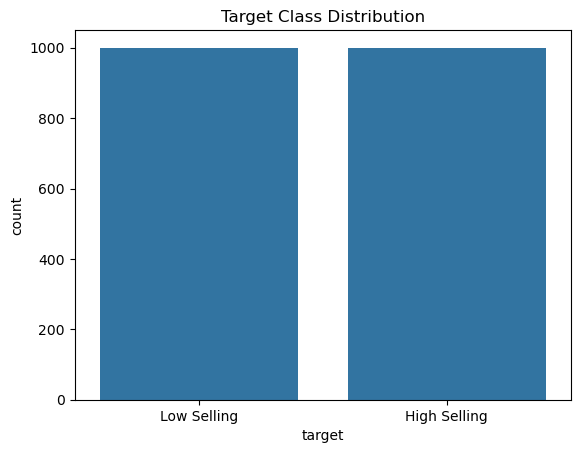

target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [986]:
sns.countplot(x=df['target'])
plt.xticks([0,1], ['Low Selling', 'High Selling'])
plt.title("Target Class Distribution")
plt.show()

print(df['target'].value_counts(normalize=True))

---
## 4. Feature Engineering

Additional features were created to improve model learning:

1. **price_per_rating**  
   Indicates product value relative to customer satisfaction.

2. **is_premium**  
   Binary flag for products priced above the 75th percentile.

3. **high_rating**  
   Indicates whether rating is 4 or above.

4. **discount_category**  
   Categorized discount into Low, Medium, and High ranges.

These features aim to capture pricing strategy, product positioning, and customer perception patterns.


In [989]:
# 1. Value indicator
df['price_per_rating'] = df['price'] / (df['rating'] + 0.1)

# 2. Premium product flag
df['is_premium'] = (df['price'] >= df['price'].quantile(0.75)).astype(int)

# 3. High rating flag
df['high_rating'] = (df['rating'] >= 4).astype(int)

# 4. Discount category 
df['discount_category'] = pd.cut(df['discount_percent'], 
                                   bins=[-1, 5, 15, 100],
                                   labels=['Low', 'Medium', 'High'])

df.head(3)

,product_id,category,subcategory,price,discount_percent,color,size,fabric,season,rating,target,price_per_rating,is_premium,high_rating,discount_category
0,P1125,Jeans,Skinny,612.55,5.0,Red,S,Georgette,Summer,1.1,1,510.458333,0,0,Low
1,P1287,Kurti,Straight,2774.10,5.0,Maroon,L,Linen,Winter,4.2,0,645.139535,0,1,Low
2,P1142,Dress,Evening,3641.63,5.0,Navy,L,Cotton,Summer,3.0,0,1174.719355,0,0,Low


---
## 5. Feature Encoding & Data Partitioning

Categorical features were converted into numerical format using One-Hot Encoding.

The `product_id` column was removed as it does not provide predictive value.

### 5.1 Categorical Encoding



In [992]:
df_model = df.drop(columns=['product_id'])

# One-hot encode (convert categories to binary columns)
df_encoded = pd.get_dummies(df_model, drop_first=True)

print("Final Feature Count:", df_encoded.shape[1])

Final Feature Count: 46


---
### 5.2 Train-Test Split

The dataset was split into:
- 80% Training data
- 20% Testing data

Stratified splitting was used to maintain class balance.

In [995]:
# Separate features (X) and target (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split into train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y, 
    test_size=0.2,     
    random_state=42,    
    stratify=y)

## 6.Model Training
### 6.1 Baseline Random Forest

Random Forest Classifier was chosen because:

- It handles structured tabular data effectively.
- Captures non-linear relationships.
- Provides feature importance.
- Reduces overfitting compared to a single decision tree.

In [998]:
# Create and train Random Forest
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # Limit depth to prevent overfitting
    random_state=42,
    n_jobs=-1            # Use all CPU cores
)

model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

### 6.2 Regularized Random Forest

In [1040]:
regularized_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

regularized_model.fit(X_train, y_train)

y_pred_reg = regularized_model.predict(X_test)

reg_test_acc = accuracy_score(y_test, y_pred_reg)

print("Regularized Test Accuracy:", reg_test_acc)

Regularized Test Accuracy: 0.5


---
### 6.3 Accuracy Comparison : Baseline vs. Regularized

In [1042]:
comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Regularized RF"],
    "Train Accuracy": [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_train, regularized_model.predict(X_train))
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_test),
        reg_test_acc
    ]
})

comparison

,Model,Train Accuracy,Test Accuracy
0,Baseline RF,0.966250,0.5125
1,Regularized RF,0.703125,0.5000


---
The regularized model reduced the training accuracy and narrowed the gap between training and testing performance.

However, test accuracy did not significantly improve, suggesting that model complexity was not the primary limitation.

This indicates that the available features may not provide strong predictive separation between classes.

---


## 7.Model Evaluation

Model (Baseline RF) performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Since the dataset is balanced, these metrics provide a fair evaluation of performance.
### 7.1 Performance Metrics

In [1008]:
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Testing Accuracy:  {test_accuracy:.2%}")
print(f"Precision:         {precision:.2%}")
print(f"Recall:            {recall:.2%}")
print(f"F1 Score:          {f1:.2%}")

Training Accuracy: 96.62%
Testing Accuracy:  51.25%
Precision:         51.27%
Recall:            50.50%
F1 Score:          50.88%


### 7.2 Classifcation Report

In [1011]:
print(classification_report(y_test, y_pred_test, target_names=['Low Selling', 'High Selling']))

              precision    recall  f1-score   support

 Low Selling       0.51      0.52      0.52       200
High Selling       0.51      0.51      0.51       200

    accuracy                           0.51       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.51      0.51      0.51       400




### 7.3 Confusion Matrix

The confusion matrix provides insight into:

- True Positives (correct High Selling predictions)
- True Negatives (correct Low Selling predictions)
- False Positives
- False Negatives


[[104  96]
 [ 99 101]]

True Negatives (Low correctly predicted):  104
False Positives (Low predicted as High):   96
False Negatives (High predicted as Low):   99
True Positives (High correctly predicted): 101



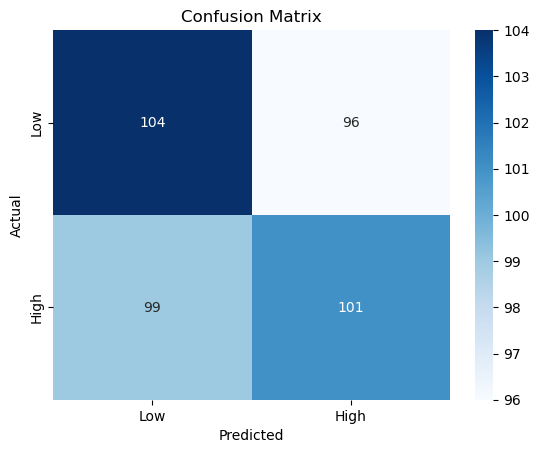

In [1118]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(f"\nTrue Negatives (Low correctly predicted):  {cm[0,0]}")
print(f"False Positives (Low predicted as High):   {cm[0,1]}")
print(f"False Negatives (High predicted as Low):   {cm[1,0]}")
print(f"True Positives (High correctly predicted): {cm[1,1]}\n")


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

---
## 8. Feature Importance

Feature importance analysis helps identify which variables most influence the prediction of product sales category.

Top contributing features include:

- Price
- Price per Rating
- Rating
- Discount Percent

This suggests pricing strategy and customer satisfaction play significant roles in product performance.


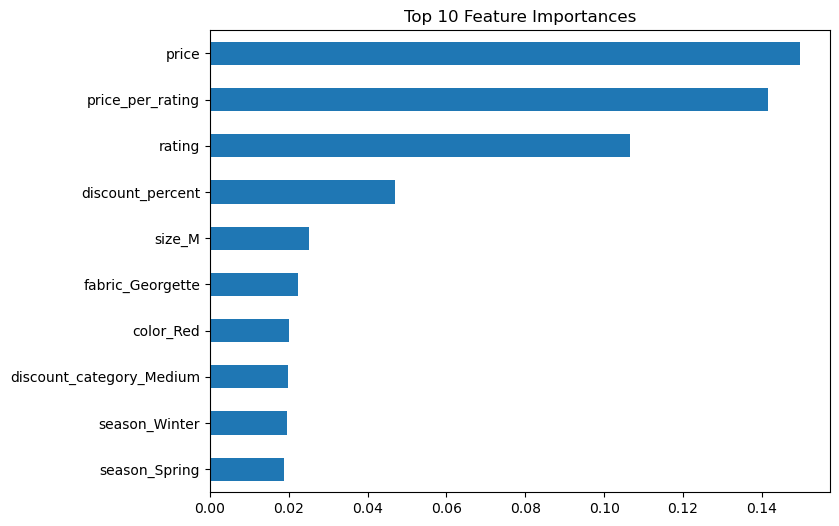

In [1026]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Feature Importances")
plt.show()

---
## 9. Overfitting& Generalization Analysis

The baseline Random Forest achieved high training accuracy (~ 96%) but much lower test accuracy (~ 51%), indicating overfitting.

This large gap suggests the model memorized training data patterns but failed to generalize well to unseen data.

After reducing model complexity (limiting tree depth and increasing minimum samples per split), the training accuracy decreased and the gap narrowed. However, test accuracy did not improve significantly.

This indicates that the limitation is not only model complexity, but also weak predictive signal in the available features.

Overall, the structured product attributes alone may not be sufficient to strongly distinguish High Selling from Low Selling products.

---

## 10. Final Conclusion

- The Random Forest model achieved strong training performance but showed limited generalization on unseen data.

- Test accuracy remained moderate (~50%), indicating weak predictive separability between High Selling and Low Selling products.

- Overfitting was observed, and although regularization reduced the training–testing gap, overall test performance did not improve significantly.

- Feature importance analysis suggests that price and rating-related attributes contribute most to predictions, but they are not sufficient for robust classification.

**Business Insight**

The current structured product attributes alone may not fully explain sales performance.

Incorporating additional business-driven variables such as marketing exposure, inventory availability, time-series demand trends, or customer behavior data may significantly enhance predictive capability.